In [3]:
!python3 -m venv .venv
!.venv/bin/python -m pip install scikit-learn keras tensorflow ipykernel


  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached requests-2.33.1-py3-none-any.whl.metadata (4.8 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached charset_normalizer-3.4.7-cp313-cp313-macosx_10_13_universal2.whl.metadata (40 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached urllib3-2.6.3-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.2.25-py3-none-any.whl.metadata (2.5 kB)
  Using cached appnope-0.1.4-py2.py3-none-any.whl.metadata (908 bytes)
  Using cached nest_asyncio-1.6.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached psutil

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
import keras
from keras.models import Sequential
from keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from sklearn.model_selection import train_test_split
import sklearn

ModuleNotFoundError: No module named 'sklearn'

In [3]:
keras.backend.backend()

'tensorflow'

## Data: circle
To make it simple, the circle touches the boundaries. We create a train and a test dataset

In [4]:
N = 500
np.random.seed(12345)
train_x = np.random.random((N,2)) * 2.0 - 1.0
train_y = np.array([((train_x[:,0]**2+train_x[:,1]**2)<1) + 0,((train_x[:,0]**2+train_x[:,1]**2)>=1) + 0]).T
test_x = np.random.random((N,2)) * 2.0 - 1.0
test_y = np.array([((test_x[:,0]**2+test_x[:,1]**2)<1) + 0,((test_x[:,0]**2+test_x[:,1]**2)>=1) + 0]).T

(-1.0979157410375773,
 1.0986733034978915,
 -1.0989916969023383,
 1.0835449218175306)

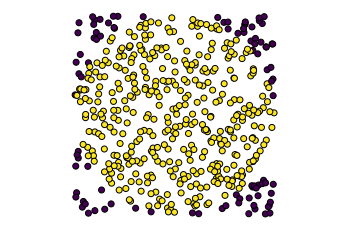

In [6]:
plt.scatter(train_x[:,0],train_x[:,1],c=train_y[:,0],edgecolors='black')
plt.axis('equal')
plt.axis('off')

## Scikit-learn
The scikit package has a very simple feedforward dense neural network implementation, called Multi-layer Perceptron classifier or `MLPClassifier`

 * The `hidden_layer_sizes` parameter lists the hidden layers. In the example below there will be one sinlge layer with five neurons. e.g. `hidden_layer_sizes=(5,7)` would mean two hidden layers, the first with 5 the second with 7 neurons. The input and output layers are determined by the data.
 * `max_iter`: sets the number of iterations or epochs for which the network is trained
 * ` alpha` is the l2 regularization parameter
 * `learning_rate_init`: the name tells everything
 * `activation`: the activation function
 * `solver`: the optimization method used. Please refer to the manual for the list of available optimizers

In [12]:
mlp = MLPClassifier(hidden_layer_sizes=(5), max_iter=1000, alpha=1e-4,
                    solver='adam', verbose=10,
                    learning_rate_init=.1,activation='logistic')

In [8]:
?MLPClassifier

Init signature:
MLPClassifier(
    hidden_layer_sizes=(100,),
    activation='relu',
    *,
    solver='adam',
    alpha=0.0001,
    batch_size='auto',
    learning_rate='constant',
    learning_rate_init=0.001,
    power_t=0.5,
    max_iter=200,
    shuffle=True,
    random_state=None,
    tol=0.0001,
    verbose=False,
    warm_start=False,
    momentum=0.9,
    nesterovs_momentum=True,
    early_stopping=False,
    validation_fraction=0.1,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-08,
    n_iter_no_change=10,
    max_fun=15000,
)
Docstring:     
Multi-layer Perceptron classifier.

This model optimizes the log-loss function using LBFGS or stochastic
gradient descent.

.. versionadded:: 0.18

Parameters
----------
hidden_layer_sizes : array-like of shape(n_layers - 2,), default=(100,)
    The ith element represents the number of neurons in the ith
    hidden layer.

activation : {'identity', 'logistic', 'tanh', 'relu'}, default='relu'
    Activation function for the hidden laye

In [13]:
mlp.fit(train_x, train_y)

Iteration 1, loss = 1.21315155
Iteration 2, loss = 0.98565826
Iteration 3, loss = 0.98702401
Iteration 4, loss = 0.99920420
Iteration 5, loss = 0.99318775
Iteration 6, loss = 0.98206658
Iteration 7, loss = 0.97348114
Iteration 8, loss = 0.96933677
Iteration 9, loss = 0.96991541
Iteration 10, loss = 0.96935062
Iteration 11, loss = 0.96330036
Iteration 12, loss = 0.95677983
Iteration 13, loss = 0.95177990
Iteration 14, loss = 0.95016810
Iteration 15, loss = 0.94521960
Iteration 16, loss = 0.93912881
Iteration 17, loss = 0.93480590
Iteration 18, loss = 0.93006686
Iteration 19, loss = 0.92404511
Iteration 20, loss = 0.91807441
Iteration 21, loss = 0.91352035
Iteration 22, loss = 0.90747807
Iteration 23, loss = 0.90185734
Iteration 24, loss = 0.89973318
Iteration 25, loss = 0.89406930
Iteration 26, loss = 0.88810803
Iteration 27, loss = 0.88104358
Iteration 28, loss = 0.87123974
Iteration 29, loss = 0.86062365
Iteration 30, loss = 0.84658310
Iteration 31, loss = 0.83313977
Iteration 32, los

MLPClassifier(activation='logistic', hidden_layer_sizes=5,
              learning_rate_init=0.1, max_iter=1000, verbose=10)

In [14]:
print("Training set score: %f" % mlp.score(train_x, train_y))
print("Test set score: %f" % mlp.score(test_x, test_y))

Training set score: 0.980000
Test set score: 0.966000


### Test the results
<b>Important:</b> In some cases the network does not converge to a nice solution, which is also indicated by a low (<0.9) score. Rerun the training by initializing the network with new random weight, which means running `MLPClassifier` again.

In [15]:
predictions = mlp.predict(test_x)

Text(0.5, 1.0, 'PREDICTIONS')

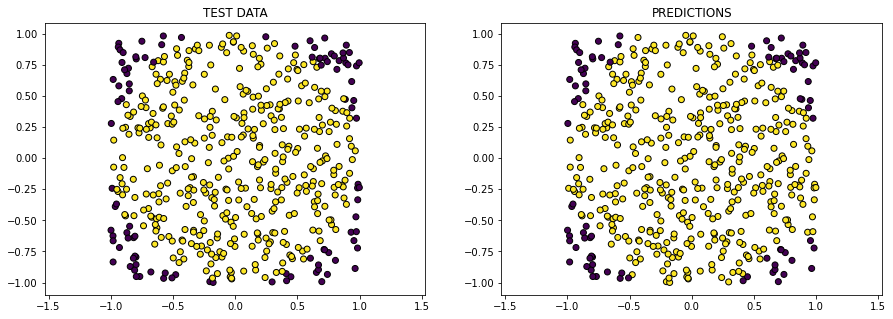

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(15,5))
ax1.scatter(test_x[:,0],test_x[:,1],c=test_y[:,0],edgecolors='black')
ax2.scatter(test_x[:,0],test_x[:,1],c=predictions[:,0],edgecolors='black')
ax1.axis('equal')
ax2.axis('equal')
# add titles to axes
ax1.set_title('TEST DATA')
ax2.set_title('PREDICTIONS')

### Decision boundaries
The decision boundaries can be visualized of we create a dense grid data

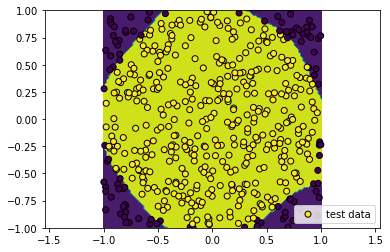

In [21]:
NG = 100
gx, gy = np.meshgrid(np.linspace(-1, 1, NG),np.linspace(-1, 1, NG))
fgx = gx.flatten()
fgy = gy.flatten()
grid = np.array([fgx,fgy]).T
C = mlp.predict(grid)[:,0].reshape(NG,NG)
plt.contourf(gx,gy,C)
plt.scatter(test_x[:,0],test_x[:,1],c=test_y[:,0],edgecolors='black',label='test data')
plt.legend()
plt.axis('equal')
plt.show()

### Weights, biases
We can print and plot the weights and the biases. The individual decision lines show the decision boundaries. The curvature comes from the activation function.

In [22]:
w = mlp.coefs_[0]
b = mlp.intercepts_[0]

In [23]:
train_x.shape

(500, 2)

In [24]:
w.shape

(2, 5)

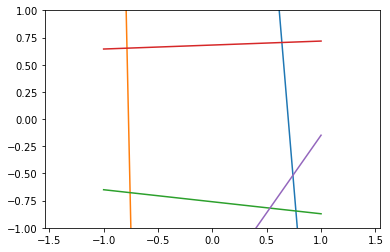

In [25]:
x = np.linspace(-1,1)
plt.axis('equal')
plt.axis((-1,1,-1,1))
for i in range(5):
    plt.plot(x,(x*w[0][i]+b[i])/w[1][i])


## Keras (tensorflow interface)
A more advanced system: <b>Keras</b>. In the machine learning world there are two very powerful neural network backends: `pytorch` and `tensorflow`. They are very well optimized and powerful. In order to facilitate their usage people often use front ends which facilitates and demistifies their usage. One of the most popular ones is Keras. It has simple models like `Sequential` in which one can simply stack layers one after the other.

The layers can be assigned to the model directly or through a variable. If you want to reset the weight, you have to rerun this cell:

In [31]:
model = Sequential()
D = Dense(10, input_shape=(2,), activation='relu')
model.add(D)
model.add(Dense(10, activation='relu'))
model.add(Dense(2, activation='sigmoid'))

`compile` creates the model and sets all model parameters, like optimizer, loss, learning rate, etc.

In [32]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

`summary` displays the model with the name of the layers (useful for e.g. transfer learning) and the number of parameters, which is a good indication about the complexity of the porblem, the expeted learning time, memory usage, etc.

In [33]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │            22 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162 (648.00 B)

 Trainable params: 162 (648.00 B)

 Non-trainable params: 0 (0.00 B)

`fit` trains the model for the given number of epochs. If the accuracy still evolves just rerun this line to teach the model further. For validation we will use the test dataset.

In [34]:
history = model.fit(train_x,train_y, epochs=150, batch_size=30, validation_data=(test_x, test_y))

Epoch 1/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.6461 - loss: 0.6875 - val_accuracy: 0.7340 - val_loss: 0.6778
Epoch 2/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7817 - loss: 0.6714 - val_accuracy: 0.7940 - val_loss: 0.6654
Epoch 3/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7883 - loss: 0.6640 - val_accuracy: 0.7940 - val_loss: 0.6522
Epoch 4/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8057 - loss: 0.6404 - val_accuracy: 0.7940 - val_loss: 0.6365
Epoch 5/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7977 - loss: 0.6302 - val_accuracy: 0.7940 - val_loss: 0.6191
Epoch 6/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7752 - loss: 0.6214 - val_accuracy: 0.7940 - val_loss: 0.6027
Epoch 7/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8028 - loss: 0.5875 - val_accuracy: 0.7940 - val_loss: 0.5855
Epoch 8/150
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7910 - loss: 0.5761 - val_accuracy: 0.

In [35]:
predictions = model.predict(test_x)
predictions

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


array([[9.84162450e-01, 2.42814142e-02],
       [1.34557709e-01, 7.90492058e-01],
       [9.91251051e-01, 1.38010411e-02],
       [9.99956012e-01, 1.71146530e-04],
       [9.87228990e-01, 2.44925674e-02],
       [9.85149145e-01, 2.82940604e-02],
       [9.94941831e-01, 1.13531500e-02],
       [9.34752464e-01, 8.71513933e-02],
       [8.63675773e-01, 1.37891889e-01],
       [9.99998271e-01, 1.42647432e-05],
       [2.34942213e-01, 6.74397171e-01],
       [9.96363044e-01, 8.10589176e-03],
       [4.78038818e-01, 4.55057561e-01],
       [9.99865413e-01, 4.07877902e-04],
       [9.99993980e-01, 3.57447061e-05],
       [9.29956257e-01, 1.03476435e-01],
       [9.96666551e-01, 7.85536878e-03],
       [9.52362657e-01, 6.72272444e-02],
       [9.96907830e-01, 5.98540809e-03],
       [9.99654233e-01, 1.10182515e-03],
       [3.93890291e-02, 9.07385349e-01],
       [9.89019036e-01, 2.10999791e-02],
       [2.20987990e-01, 7.53824115e-01],
       [9.63460088e-01, 5.26353568e-02],
       [9.998251

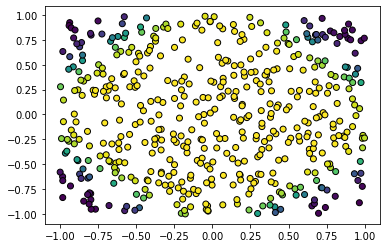

In [36]:
plt.scatter(test_x[:,0],test_x[:,1],c=predictions[:,0],edgecolors='black')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


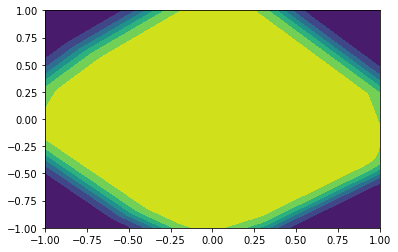

In [37]:
NG = 100
gx, gy = np.meshgrid(np.linspace(-1, 1, NG),np.linspace(-1, 1, NG))
fgx = gx.flatten()
fgy = gy.flatten()
grid = np.array([fgx,fgy]).T
C = model.predict(grid)[:,0].reshape(NG,NG)
plt.contourf(gx,gy,C)
plt.show()

In [38]:
model.get_weights()

[array([[-0.02742736,  1.2912269 ,  0.04177505, -1.3019288 , -0.16782974,
          0.28924656, -0.413468  , -0.3872222 , -0.10269789,  0.5619857 ],
        [-0.05988996, -0.13278463,  0.60997057, -0.29042375,  1.1147066 ,
          1.0197147 , -0.0329562 , -0.6092757 , -0.92499673, -0.07285718]],
       dtype=float32),
 array([ 0.59268075, -0.10318566,  0.61896294,  0.12238324, -0.09972265,
         0.00249561,  0.61955994,  0.08618298, -0.24357301,  0.6032646 ],
       dtype=float32),
 array([[ 3.9684838e-01,  7.8754956e-01,  1.4038235e-01,  7.9645091e-01,
          3.7231475e-01,  1.3277763e-01, -2.5886446e-01,  5.9413069e-01,
          9.3026233e-01,  7.4977255e-01],
        [-7.5758255e-01, -8.9052421e-01,  1.5387394e-01, -1.4165950e+00,
         -1.2249390e+00,  8.2275283e-01, -4.5793673e-01, -1.1173254e+00,
         -1.0708717e+00,  1.4847274e+00],
        [ 3.4137321e-01,  5.5963778e-01,  7.9817865e-03,  2.2584163e-01,
          2.7676737e-01, -2.2020395e+00, -3.7938336e-01,  5

In [39]:
w,b = D.get_weights()
print(w)

[[-0.02742736  1.2912269   0.04177505 -1.3019288  -0.16782974  0.28924656
  -0.413468   -0.3872222  -0.10269789  0.5619857 ]
 [-0.05988996 -0.13278463  0.60997057 -0.29042375  1.1147066   1.0197147
  -0.0329562  -0.6092757  -0.92499673 -0.07285718]]


`plot_history` is a nice function which allows you to plot the accuracy and the loss as function of the epoch. It is easy to see if the learning did not finish, or we are already in the overfitting regime.

In [40]:
# https://www.kaggle.com/danbrice/keras-plot-history-full-report-and-grid-search
def plot_history(history):
    loss_list = [s for s in history.history.keys() if 'loss' in s and 'val' not in s]
    val_loss_list = [s for s in history.history.keys() if 'loss' in s and 'val' in s]
    acc_list = [s for s in history.history.keys() if 'acc' in s and 'val' not in s]
    val_acc_list = [s for s in history.history.keys() if 'acc' in s and 'val' in s]
    
    if len(loss_list) == 0:
        print('Loss is missing in history')
        return 
    
    ## As loss always exists
    epochs = range(1,len(history.history[loss_list[0]]) + 1)
    ## Loss
    plt.figure(1)
    for l in loss_list:
        plt.plot(epochs, history.history[l], 'b', label='Training loss (' + str(str(format(history.history[l][-1],'.5f'))+')'))
    for l in val_loss_list:
        plt.plot(epochs, history.history[l], 'g', label='Validation loss (' + str(str(format(history.history[l][-1],'.5f'))+')'))
    
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    ## Accuracy
    plt.figure(2)
    for l in acc_list:
        plt.plot(epochs, history.history[l], 'b', label='Training accuracy (' + str(format(history.history[l][-1],'.5f'))+')')
    for l in val_acc_list:    
        plt.plot(epochs, history.history[l], 'g', label='Validation accuracy (' + str(format(history.history[l][-1],'.5f'))+')')

    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()


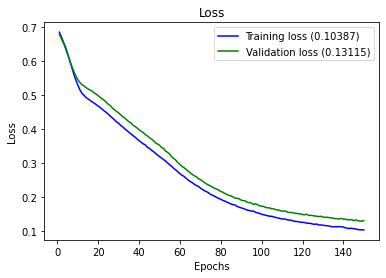

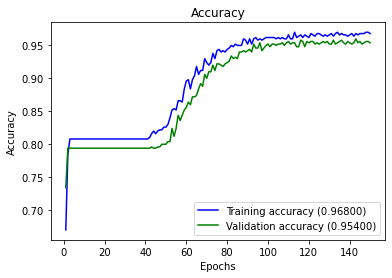

In [41]:
plot_history(history)

# Regularization
Create a new more complicated dataset:

In [42]:
N = 500
np.random.seed(12345)
train_x = np.random.random((N,2)) * 2.0 - 1.0
cond = ((train_x[:,0]**2+train_x[:,1]**2)<1)  * ((train_x[:,0]**2+train_x[:,1]**2)>0.25)
train_y = np.array([cond*1,1-cond*1]).T
test_x = np.random.random((N,2)) * 2.0 - 1.0
cond = ((test_x[:,0]**2+test_x[:,1]**2)<1)  * ((test_x[:,0]**2+test_x[:,1]**2)>0.25)
test_y = np.array([cond*1,1-cond*1]).T

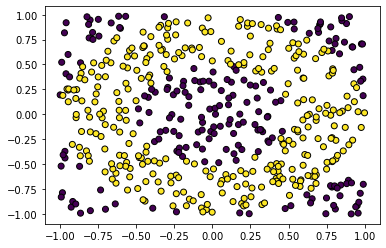

In [43]:
plt.scatter(train_x[:,0],train_x[:,1],c=train_y[:,0],edgecolors='black')

In [44]:
model = Sequential()
model.add(Dense(30, input_shape=(2,),activation='relu'))
model.add(Dense(30,activation='relu'))
model.add(Dense(2, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [45]:
history = model.fit(train_x,train_y, epochs=200, batch_size=20, validation_data=(test_x, test_y))

Epoch 1/500


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.4985 - loss: 0.6909 - val_accuracy: 0.5960 - val_loss: 0.6838
Epoch 2/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6145 - loss: 0.6773 - val_accuracy: 0.5860 - val_loss: 0.6771
Epoch 3/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5879 - loss: 0.6723 - val_accuracy: 0.5860 - val_loss: 0.6736
Epoch 4/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6423 - loss: 0.6516 - val_accuracy: 0.5860 - val_loss: 0.6714
Epoch 5/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6056 - loss: 0.6589 - val_accuracy: 0.5860 - val_loss: 0.6694
Epoch 6/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.5846 - loss: 0.6672 - val_accuracy: 0.5860 - val_loss: 0.6681
Epoch 7/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6072 - loss: 0.6549 - val_accuracy: 0.5860 - val_loss: 0.6655
Epoch 8/500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6295 - loss: 0.6361 - val_accuracy: 0.5860 - val_l

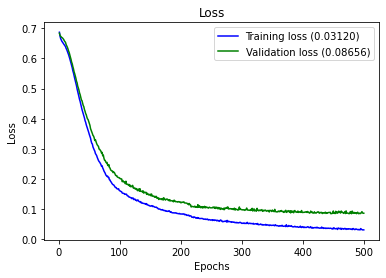

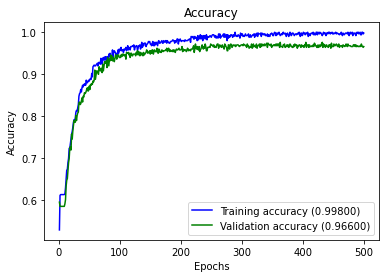

In [46]:
plot_history(history)

In [47]:
l2 = 1e-4
l1 = 1e-4
model_reg = Sequential()
model_reg.add(Dense(30, input_shape=(2,), activation='relu',
            kernel_regularizer=keras.regularizers.l1_l2(l1=l1, l2=l2),
            bias_regularizer=keras.regularizers.l2(l2),
            activity_regularizer=keras.regularizers.l2(l2)))
model_reg.add(Dense(30, activation='relu',
            kernel_regularizer=keras.regularizers.l1_l2(l1=l1, l2=l2),
            bias_regularizer=keras.regularizers.l2(l2),
            activity_regularizer=keras.regularizers.l2(l2)))
model_reg.add(Dense(2, activation='sigmoid'))
model_reg.compile(loss='binary_crossentropy', optimizer= 'Adam', metrics=['accuracy'])

In [55]:
history_reg = model_reg.fit(train_x,train_y, epochs=500, batch_size=10, validation_data=(test_x, test_y))

Epoch 1/500
 1/50 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.9000 - loss: 0.2469

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9549 - loss: 0.1927 - val_accuracy: 0.9340 - val_loss: 0.2305
Epoch 2/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9676 - loss: 0.1847 - val_accuracy: 0.9520 - val_loss: 0.2217
Epoch 3/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9662 - loss: 0.1894 - val_accuracy: 0.9380 - val_loss: 0.2269
Epoch 4/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9617 - loss: 0.1947 - val_accuracy: 0.9420 - val_loss: 0.2253
Epoch 5/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9653 - loss: 0.1839 - val_accuracy: 0.9540 - val_loss: 0.2198
Epoch 6/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9690 - loss: 0.1744 - val_accuracy: 0.9500 - val_loss: 0.2239
Epoch 7/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9553 - loss: 0.2024 - val_accuracy: 0.9540 - val_loss: 0.2152
Epoch 8/500
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9585 - loss: 0.1867 - val_accuracy: 0.9420 - val_los

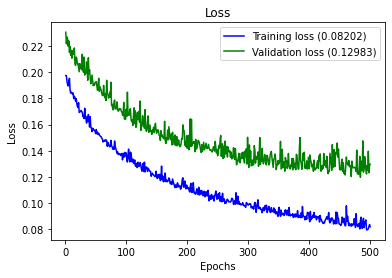

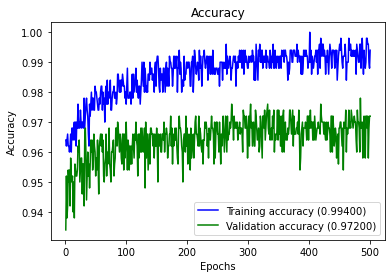

In [56]:
plot_history(history_reg)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


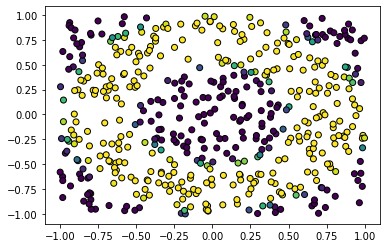

In [57]:
predictions = model.predict(test_x)
plt.scatter(test_x[:,0],test_x[:,1],c=predictions[:,0],edgecolors='black')

 1/16 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


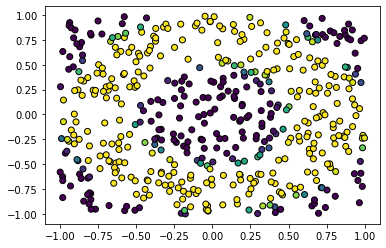

In [58]:
predictions = model_reg.predict(test_x)
plt.scatter(test_x[:,0],test_x[:,1],c=predictions[:,0],edgecolors='black')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


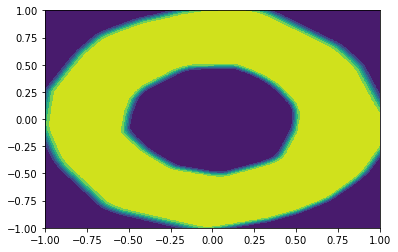

In [59]:
NG = 100
gx, gy = np.meshgrid(np.linspace(-1, 1, NG),np.linspace(-1, 1, NG))
fgx = gx.flatten()
fgy = gy.flatten()
grid = np.array([fgx,fgy]).T
C = model.predict(grid)[:,0].reshape(NG,NG)
plt.contourf(gx,gy,C)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


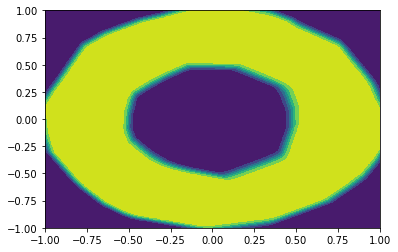

In [60]:
NG = 100
gx, gy = np.meshgrid(np.linspace(-1, 1, NG),np.linspace(-1, 1, NG))
fgx = gx.flatten()
fgy = gy.flatten()
grid = np.array([fgx,fgy]).T
C = model_reg.predict(grid)[:,0].reshape(NG,NG)
plt.contourf(gx,gy,C)
plt.show()

## Task 1
 1. Load the mnist dataset (see below) It will take time, try to download it before the class.
 * The dataset has 70000 rows and each row has 785 columns
 * In each row the first 784 is a 28x28 pixel grayscale (0-255) image of a hand written number
 * The last number is the number on the image
 * Load the dataset and plot the first 4 images
 * Split the data into training and testing data parts
 * Teach two fully connected neural networks with the training set using two different systems
 * One hidden layer with 50-100 neurons is in general enough to obtain pritty good result.
 * Test your data
 * Create a confusion matrix. $C_{ij}$ is the count for detecting an image with number $i$ as number $j$
 * Plot the confusion matrix

In [271]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

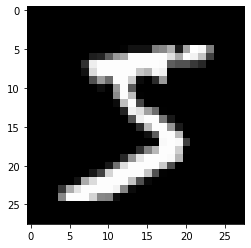

In [274]:
plt.imshow(x_train[0],cmap='gray')

In [275]:
print(y_train[0])

5


## Task 2 Red Wine challenge
 1. Load the red wine dataset `wine_red.csv` (see below): It has 11 descriptors and the last column is quality.
 2. Train any network you want, to predict the quality
 3. you may consider using 'mean_squared_error' loss function or MLPRegressor as the quality is continuous, but categorical method should work as well, but then do not forget to make a one hot encoding.
 4. Test the results using `qqq_wine_red.csv`
 5. The best one(s) will get a prize!


In [276]:
import pandas as pd

In [279]:
csv = pd.read_csv("wine_red.csv",sep=';')

In [282]:
csv

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
4,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.99640,3.30,0.46,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1115,5.4,0.74,0.09,1.7,0.089,16.0,26.0,0.99402,3.67,0.56,11.6,6
1116,6.3,0.51,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1117,6.2,0.60,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1118,5.9,0.55,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6


In [288]:
data = csv.to_numpy()
data.shape

(1120, 12)

**Use the following code to test the accuracy of your code!**

Do not forget to load the test data and apply your neural network on the test data!

In [ ]:
from sklearn.metrics import accuracy_score
print('The accuracy of my model {}'.format(accuracy_score(y_true,y_predicted)))

### Homework
Use the Fashion-MNIST datset to train a Neural Network. To test your network prepare your own test data. Look up some pictures of different clothing items (use online shops or anything you find). Write a short code that convers your image to the same format as the test data (28x28, grayscale, normalized pixels). I suggest to use `pillow`. Use 10 images, what are shown in your notebook, together with the converted gray scale images and show the result of the classification. 